# Notebook 3 - XAI Evaluation of the CBM + CEM - HuBERT backbone

Systematic evaluation using the **Co-12 framework (Nauta et al. 2023)** + intervention
test (Koh et al. 2020).

| Property | Metric |
|---|---|
| Correctness | Comprehensiveness / Sufficiency (AOPC vs random) |
| Correctness | **Distillation fidelity** + prediction agreement |
| Correctness | **Label randomization** + **parameter randomization** |
| Consistency | LOSO with per-fold retraining |  
| Contrastivity | Cosine between weight vectors vs **structural baseline −1/(C−1)** |
| Covariate complexity | Redundancy (Pearson)  |
| Controllability | Intervention curve (random + uncertainty) |
| Coherence | Psychoacoustic plausibility, **acoustic concepts only** |

Classification metrics always reported as WA/UA/macro-F1.

## 1 · Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install scikit-learn matplotlib seaborn scipy -q

In [6]:
import sys, json
import numpy as np
import torch
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.stats import spearmanr
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

PROJ = Path('/content/drive/MyDrive/XAI_SER/2_project_s346591/code')
sys.path.append(str(PROJ))
import xai_common as xc

BACKBONE = 'hubert'
PATHS = xc.get_paths(BACKBONE, PROJ)
DATA_DIR, MODEL_DIR, RESULTS_DIR = PATHS['data'], PATHS['model'], PATHS['results']
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
SESSIONS = ['1', '2', '3', '4', '5']
xc.set_seed()
print(f'Backbone: {BACKBONE}   Device: {DEVICE}')

Backbone: hubert   Device: cuda


## 2 · Pipeline reconstruction (identical to NB2)
Aggregator, scaler, probes, and models are **loaded** , not refitted.
Binarization uses the same train-only per-gender thresholds from NB2.

In [7]:
emb_data = np.load(DATA_DIR / 'layer_embeddings.npz')
valid_ids     = json.load(open(DATA_DIR / 'valid_ids.json'))
metadata      = json.load(open(DATA_DIR / 'metadata.json'))
concept_names = json.load(open(DATA_DIR / 'concept_names.json'))

X_layers = np.stack([emb_data[u] for u in valid_ids])
X_concepts_raw = np.load(DATA_DIR / 'X_concepts.npy')          # with NaN (raw version needed for LOSO)
y_emotion = np.load(DATA_DIR / 'y_emotion.npy')
sessions = np.array([metadata[u]['session'] for u in valid_ids])
genders  = np.array([metadata[u]['gender'] for u in valid_ids])

tr_mask = sessions != '5'
te_mask = ~tr_mask
y_tr, y_te = y_emotion[tr_mask], y_emotion[te_mask]
X_concepts = xc.impute_nan(X_concepts_raw, tr_mask)

aggregator = xc.WeightedAggregator().to(DEVICE)
aggregator.load_state_dict(torch.load(MODEL_DIR / 'aggregator.pt', map_location=DEVICE))
aggregator.eval()
scaler_emb = joblib.load(MODEL_DIR / 'scaler_emb.pkl')
probes     = joblib.load(MODEL_DIR / 'probes.pkl')
cbm        = joblib.load(MODEL_DIR / 'cbm_configs.pkl')['acoustic']
baseline   = joblib.load(MODEL_DIR / 'baseline.pkl')
mlp        = joblib.load(MODEL_DIR / 'mlp.pkl')

def get_weighted_repr(X_lay):
    with torch.no_grad():
        return aggregator.aggregate(torch.tensor(X_lay, dtype=torch.float32).to(DEVICE)).cpu().numpy()

X_emb_tr_sc = scaler_emb.transform(get_weighted_repr(X_layers[tr_mask]))
X_emb_te_sc = scaler_emb.transform(get_weighted_repr(X_layers[te_mask]))

EVAL_CONCEPTS = xc.ACOUSTIC_CONCEPTS
K = len(EVAL_CONCEPTS)
a_idx = [concept_names.index(c) for c in EVAL_CONCEPTS]
C_tr = xc.concept_scores(probes, X_emb_tr_sc, EVAL_CONCEPTS)
C_te = xc.concept_scores(probes, X_emb_te_sc, EVAL_CONCEPTS)
C_bin, _ = xc.binarize_concepts(X_concepts, concept_names, genders, tr_mask)
C_gt_te = C_bin[te_mask][:, a_idx].astype(np.float32)

y_pred_cbm = cbm.predict(C_te)
y_pred_mlp = mlp.predict(X_emb_te_sc)
y_pred_base = baseline.predict(X_emb_te_sc)
cbm_m, mlp_m = xc.metrics_report(y_te, y_pred_cbm), xc.metrics_report(y_te, y_pred_mlp)
print(f'CBM: {cbm_m}\nMLP: {mlp_m}')


ref = json.load(open(RESULTS_DIR / 'summary.json'))['cbm']['acoustic']['accuracy']
assert abs(cbm_m['accuracy'] - ref) < 0.01, (
    f'CBM acc {cbm_m["accuracy"]:.3f} != NB2 {ref:.3f}: representation mismatch')
print(f'[OK] NB2<->NB3 consistency verified ({cbm_m["accuracy"]:.3f} == {ref:.3f})')

# bottleneck components for the deletion metrics (standardized scale)
scaler_con = cbm.named_steps['scaler']
clf_con    = cbm.named_steps['clf']
C_tr_sc, C_te_sc = scaler_con.transform(C_tr), scaler_con.transform(C_te)
imp = np.abs(clf_con.coef_).mean(axis=0)
imp_ord = np.argsort(imp)[::-1]
print('\nConcept importance (mean |coef|, descending):')
for rank, k in enumerate(imp_ord):
    print(f'  {rank+1}. {EVAL_CONCEPTS[k]:12s} {imp[k]:.4f}')

CBM: {'accuracy': 0.4666, 'ua': 0.5255, 'macro_f1': 0.4657}
MLP: {'accuracy': 0.6559, 'ua': 0.6638, 'macro_f1': 0.6558}
[OK] NB2<->NB3 consistency verified (0.467 == 0.467)

Concept importance (mean |coef|, descending):
  1. rms_mean     0.3929
  2. alpha_ratio  0.3257
  3. speech_rate  0.2906
  4. pitch_mean   0.2097
  5. voiced_ratio 0.2005
  6. rms_cv       0.1932
  7. pitch_range  0.1831
  8. pause_dur_mean 0.1398
  9. pitch_std    0.1320
  10. rms_slope    0.1257
  11. jitter       0.1246
  12. pause_ratio  0.1001
  13. shimmer      0.0756
  14. pitch_slope  0.0547
  15. hnr          0.0263


## 3 · Faithfulness (Correctness)
### 3.1 · Comprehensiveness - deletion (AOPC vs random ordering)
Zeroing a concept on the standardized scale = bringing it back to the mean
(non-informative baseline). AOPC should be read ONLY relative to the random control.

In [10]:
def prob_of_pred(X_sc, pred):
    return clf_con.predict_proba(X_sc)[np.arange(len(pred)), pred]

base_p = prob_of_pred(C_te_sc, y_pred_cbm)

def deletion_drops(order):
    C = C_te_sc.copy(); drops = []
    for k in range(K):
        C[:, order[k]] = 0.0
        drops.append(float((base_p - prob_of_pred(C, y_pred_cbm)).mean()))
    return np.array(drops)

rng = np.random.default_rng(xc.SEED)
comp_drops = deletion_drops(imp_ord)
AOPC_comp = float(comp_drops.mean())
AOPC_comp_rand = float(np.array([deletion_drops(rng.permutation(K)) for _ in range(10)]).mean())
print(f'AOPC comprehensiveness: {AOPC_comp:.4f}   random: {AOPC_comp_rand:.4f}'
      f'   gain: {AOPC_comp - AOPC_comp_rand:+.4f} (expected > 0)')

AOPC comprehensiveness: 0.2281   random: 0.1488   gain: +0.0794 (expected > 0)


### 3.2 · Sufficiency - insertion (AOPC vs random)

AOPC sufficiency: 0.4617   random: 0.3814   gain: +0.0802 (expected > 0)


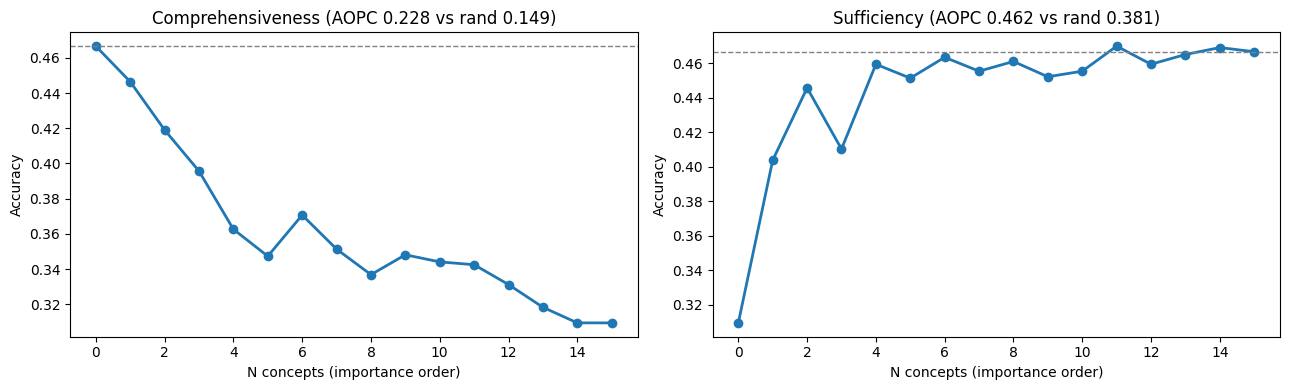

In [11]:
def keep_confidence(order):
    confs = []
    for k in range(K + 1):
        C = np.zeros_like(C_te_sc)
        if k > 0:
            C[:, order[:k]] = C_te_sc[:, order[:k]]
        confs.append(float(prob_of_pred(C, y_pred_cbm).mean()))
    return np.array(confs)

suff_conf = keep_confidence(imp_ord)
AOPC_suff = float(suff_conf[1:].mean())
AOPC_suff_rand = float(np.array([keep_confidence(rng.permutation(K)) for _ in range(10)]).mean(axis=0)[1:].mean())
print(f'AOPC sufficiency: {AOPC_suff:.4f}   random: {AOPC_suff_rand:.4f}'
      f'   gain: {AOPC_suff - AOPC_suff_rand:+.4f} (expected > 0)')

# accuracy curves (for the plot)
comp_acc = [cbm_m['accuracy']]; Cm = C_te_sc.copy()
for k in range(K):
    Cm[:, imp_ord[k]] = 0.0
    comp_acc.append(float((clf_con.predict(Cm) == y_te).mean()))
suff_acc = []
for k in range(K + 1):
    C = np.zeros_like(C_te_sc)
    if k > 0:
        C[:, imp_ord[:k]] = C_te_sc[:, imp_ord[:k]]
    suff_acc.append(float((clf_con.predict(C) == y_te).mean()))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, curve, title in [(axes[0], comp_acc, f'Comprehensiveness (AOPC {AOPC_comp:.3f} vs rand {AOPC_comp_rand:.3f})'),
                         (axes[1], suff_acc, f'Sufficiency (AOPC {AOPC_suff:.3f} vs rand {AOPC_suff_rand:.3f})')]:
    ax.plot(range(K + 1), curve, marker='o', linewidth=2)
    ax.axhline(cbm_m['accuracy'], color='gray', linestyle='--', linewidth=1)
    ax.set_xlabel('N concepts (importance order)'); ax.set_ylabel('Accuracy'); ax.set_title(title)
plt.tight_layout(); plt.savefig(RESULTS_DIR / 'faithfulness_curves.png', dpi=150); plt.show()

### 3.3 · Distillation fidelity
Fidelity is measured with a
**surrogate**: a bottleneck trained on the MLP's PREDICTIONS.

In [12]:
agreement = float((y_pred_cbm == y_pred_mlp).mean())
print(f'Prediction agreement CBM vs MLP: {agreement:.3f}')

surrogate = Pipeline([('scaler', StandardScaler()),
                      ('clf', LogisticRegression(max_iter=1000))])
surrogate.fit(C_tr, mlp.predict(X_emb_tr_sc))
fidelity = float((surrogate.predict(C_te) == y_pred_mlp).mean())
print(f'Fidelity (distilled surrogate -> MLP)        : {fidelity:.3f}')

Prediction agreement CBM vs MLP: 0.517
Fidelity (distilled surrogate -> MLP)        : 0.587


### 3.4 · Sanity checks
(a) **Label randomization**: CBM retrained on permuted labels → accuracy at
~chance and uncorrelated importances. (b) **Parameter randomization** (Adebayo):
CBM coefficients permuted → the importance ranking should collapse.

(a) Label randomization:  acc 0.321 +/- 0.023  (majority 0.356, true CBM 0.467)
    Spearman importances vs true: +0.046 +/- 0.185
    null baseline (perm-perm) : +0.194 +/- 0.268
    -> rho(true, permuted) is compatible with the null baseline: the shared
       part of the ranking is explained by the covariance of the concept scores, ok.
(b) Parameter randomization: Spearman -0.054 +/- 0.336 (expected ~0)


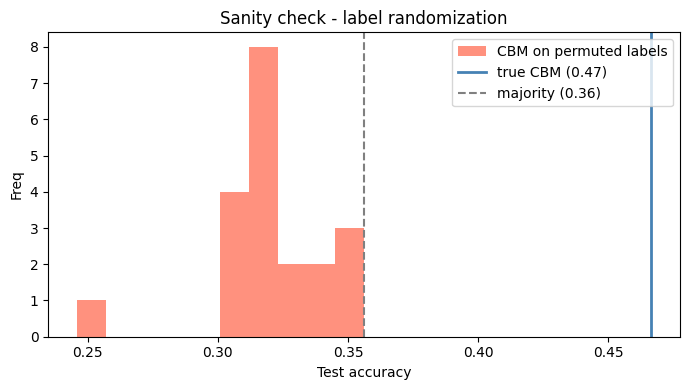

In [13]:
N_SHUFFLE = 20
shuf_acc, shuf_rho, shuf_imps = [], [], []
rng_s = np.random.default_rng(xc.SEED)
for _ in range(N_SHUFFLE):
    m = LogisticRegression(max_iter=1000).fit(C_tr_sc, rng_s.permutation(y_tr))
    shuf_acc.append(float((m.predict(C_te_sc) == y_te).mean()))
    imp_s = np.abs(m.coef_).mean(axis=0)
    shuf_imps.append(imp_s)
    shuf_rho.append(float(spearmanr(imp, imp_s)[0]))

# Null baseline for the test: correlation between the rankings of PAIRS of
# models on permuted labels. The covariance of the concept scores induces
# similar rankings even without a real label: the correct reference for
# rho(true, permuted) is this distribution, not zero.
null_rho = [float(spearmanr(shuf_imps[i], shuf_imps[j])[0])
            for i in range(N_SHUFFLE) for j in range(i + 1, N_SHUFFLE)]
chance = float(max(np.bincount(y_te)) / len(y_te))
print(f'(a) Label randomization:  acc {np.mean(shuf_acc):.3f} +/- {np.std(shuf_acc):.3f}'
      f'  (majority {chance:.3f}, true CBM {cbm_m["accuracy"]:.3f})')
print(f'    Spearman importances vs true: {np.mean(shuf_rho):+.3f} +/- {np.std(shuf_rho):.3f}')
print(f'    null baseline (perm-perm) : {np.mean(null_rho):+.3f} +/- {np.std(null_rho):.3f}')
if np.mean(shuf_rho) <= np.mean(null_rho) + np.std(null_rho):
    print('    -> rho(true, permuted) is compatible with the null baseline: the shared')
    print('       part of the ranking is explained by the covariance of the concept scores, ok.')
else:
    print('    -> rho(true, permuted) is ABOVE the null baseline: worth investigating.')

param_rho = []
for _ in range(N_SHUFFLE):
    coef_rand = rng_s.permutation(clf_con.coef_.ravel()).reshape(clf_con.coef_.shape)
    param_rho.append(float(spearmanr(imp, np.abs(coef_rand).mean(axis=0))[0]))
print(f'(b) Parameter randomization: Spearman {np.mean(param_rho):+.3f} +/- {np.std(param_rho):.3f} (expected ~0)')

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(shuf_acc, bins=10, color='tomato', alpha=0.7, label='CBM on permuted labels')
ax.axvline(cbm_m['accuracy'], color='steelblue', linewidth=2, label=f'true CBM ({cbm_m["accuracy"]:.2f})')
ax.axvline(chance, color='gray', linestyle='--', label=f'majority ({chance:.2f})')
ax.set_xlabel('Test accuracy'); ax.set_ylabel('Freq'); ax.legend()
ax.set_title('Sanity check - label randomization')
plt.tight_layout(); plt.savefig(RESULTS_DIR / 'sanity_check.png', dpi=150); plt.show()

## 4 · Consistency - LOSO without leakage
For each fold EVERYTHING is retrained using only that fold's train data,
including the **binarization thresholds** .

In [14]:
fold_importances, fold_metrics = [], []
for test_sess in SESSIONS:
    trm = sessions != test_sess
    tem = ~trm
    inner_val_f = sessions[trm] == sorted(set(sessions[trm]))[-1]

    # 1) aggregator
    agg_f, _ = xc.train_aggregator(X_layers[trm], y_emotion[trm], inner_val_f, device=DEVICE)
    with torch.no_grad():
        e_tr = agg_f.aggregate(torch.tensor(X_layers[trm], dtype=torch.float32).to(DEVICE)).cpu().numpy()
        e_te = agg_f.aggregate(torch.tensor(X_layers[tem], dtype=torch.float32).to(DEVICE)).cpu().numpy()
    sc_e = StandardScaler().fit(e_tr)
    e_tr_sc, e_te_sc = sc_e.transform(e_tr), sc_e.transform(e_te)

    # 2) imputation + binarization using ONLY the fold's train statistics
    Xc_f = xc.impute_nan(X_concepts_raw, trm)
    C_bin_f, _ = xc.binarize_concepts(Xc_f, concept_names, genders, trm)
    Cb_tr, Cb_te = C_bin_f[trm][:, a_idx], C_bin_f[tem][:, a_idx]

    # 3) fold's probes + CBM
    probes_f = xc.fit_probes(e_tr_sc, Cb_tr, EVAL_CONCEPTS, inner_val=inner_val_f)
    Cf_tr = xc.concept_scores(probes_f, e_tr_sc, EVAL_CONCEPTS)
    Cf_te = xc.concept_scores(probes_f, e_te_sc, EVAL_CONCEPTS)
    cbm_f = xc.fit_cbm_head(Cf_tr, y_emotion[trm], inner_val=inner_val_f)

    fold_importances.append(np.abs(cbm_f.named_steps['clf'].coef_).mean(axis=0))
    fold_metrics.append(xc.metrics_report(y_emotion[tem], cbm_f.predict(Cf_te)))
    top = EVAL_CONCEPTS[int(np.argmax(fold_importances[-1]))]
    print(f'  Fold test={test_sess}: {fold_metrics[-1]}  top concept = {top}')

rhos = [float(spearmanr(fold_importances[i], fold_importances[j])[0])
        for i in range(len(SESSIONS)) for j in range(i + 1, len(SESSIONS))]
loso_acc = [m['accuracy'] for m in fold_metrics]
loso_ua  = [m['ua'] for m in fold_metrics]
print(f'\nLOSO: acc {np.mean(loso_acc):.3f} +/- {np.std(loso_acc):.3f}'
      f'   UA {np.mean(loso_ua):.3f} +/- {np.std(loso_ua):.3f}')
print(f'Spearman rank corr (10 pairs): {np.mean(rhos):.3f} +/- {np.std(rhos):.3f}')

  Fold test=1: {'accuracy': 0.4258, 'ua': 0.5, 'macro_f1': 0.4162}  top concept = rms_mean
  Fold test=2: {'accuracy': 0.4673, 'ua': 0.5066, 'macro_f1': 0.4735}  top concept = rms_mean
  Fold test=3: {'accuracy': 0.4883, 'ua': 0.4941, 'macro_f1': 0.4724}  top concept = rms_mean
  Fold test=4: {'accuracy': 0.4646, 'ua': 0.4768, 'macro_f1': 0.4494}  top concept = rms_mean
  Fold test=5: {'accuracy': 0.4649, 'ua': 0.5233, 'macro_f1': 0.464}  top concept = rms_mean

LOSO: acc 0.462 +/- 0.020   UA 0.500 +/- 0.015
Spearman rank corr (10 pairs): 0.876 +/- 0.066


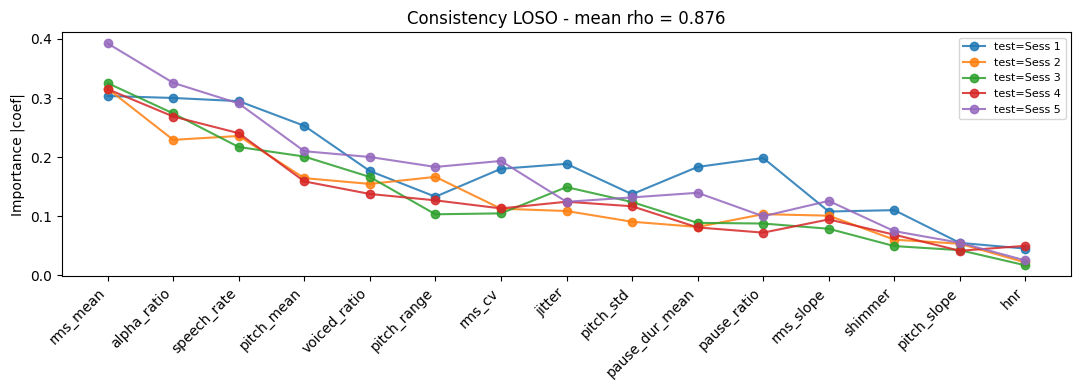

In [15]:
fig, ax = plt.subplots(figsize=(11, 4))
order = np.argsort(np.mean(fold_importances, axis=0))[::-1]
for sess, imp_f in zip(SESSIONS, fold_importances):
    ax.plot(range(K), np.array(imp_f)[order], marker='o', linewidth=1.5, label=f'test=Sess {sess}', alpha=0.85)
ax.set_xticks(range(K)); ax.set_xticklabels([EVAL_CONCEPTS[i] for i in order], rotation=45, ha='right')
ax.set_ylabel('Importance |coef|')
ax.set_title(f'Consistency LOSO - mean rho = {np.mean(rhos):.3f}')
ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig(RESULTS_DIR / 'consistency.png', dpi=150); plt.show()

## 5 · Contrastivity - with structural baseline
In a multinomial logistic regression with C classes, the weight vectors are
constrained (sum ~0): the expected cosine between classes even AT RANDOM is
≈ −1/(C−1) = −0.33. Contrastivity should be read as a deviation from this
baseline (and from a model on permuted labels), not as an absolute value.

Mean off-diagonal cosine : -0.279
Structural baseline      : -0.333   permuted labels: -0.308 +/- 0.018
Deviation from baseline       : +0.054 (more negative = classes more contrastive than chance)
[VERDICT] No evidence of contrastivity beyond chance: the model's cosine is
not more negative than the baselines (structural and permuted labels).


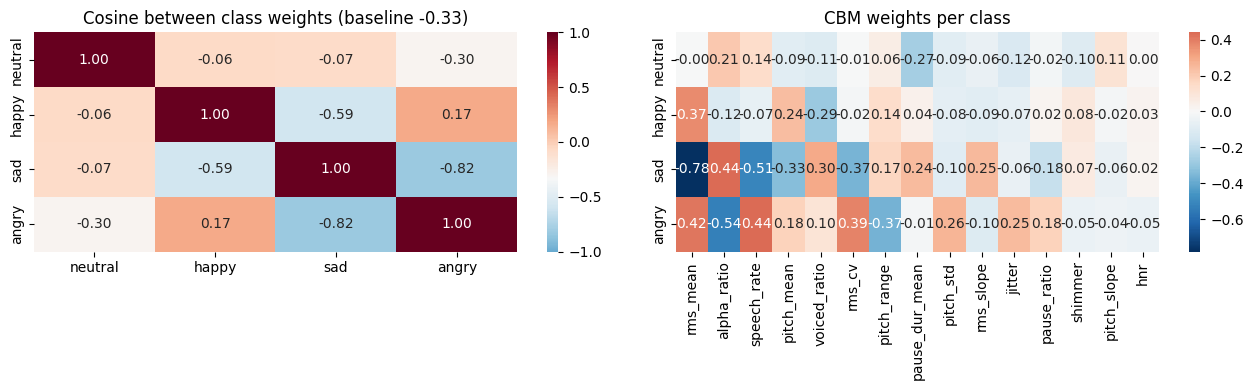

In [16]:
from numpy.linalg import norm

def mean_offdiag_cos(coefs):
    nC = len(coefs)
    vals = [float(coefs[i] @ coefs[j] / (norm(coefs[i]) * norm(coefs[j])))
            for i in range(nC) for j in range(i + 1, nC)]
    return float(np.mean(vals)), vals

cos_mean, _ = mean_offdiag_cos(clf_con.coef_)
expected = -1.0 / (len(xc.LABEL_NAMES) - 1)
sh_cos = [mean_offdiag_cos(LogisticRegression(max_iter=1000)
          .fit(C_tr_sc, rng.permutation(y_tr)).coef_)[0] for _ in range(10)]
print(f'Mean off-diagonal cosine : {cos_mean:+.3f}')
print(f'Structural baseline      : {expected:+.3f}   permuted labels: {np.mean(sh_cos):+.3f} +/- {np.std(sh_cos):.3f}')
print(f'Deviation from baseline       : {cos_mean - expected:+.3f} (more negative = classes more contrastive than chance)')
if (cos_mean - expected) >= 0 or (cos_mean - float(np.mean(sh_cos))) >= 0:
    print('[VERDICT] No evidence of contrastivity beyond chance: the model\'s cosine is')
    print('not more negative than the baselines (structural and permuted labels).')
else:
    print('[VERDICT] Classes more contrastive than both baselines.')

nC = len(xc.LABEL_NAMES)
cos_sim = np.array([[float(clf_con.coef_[i] @ clf_con.coef_[j] /
                          (norm(clf_con.coef_[i]) * norm(clf_con.coef_[j])))
                     for j in range(nC)] for i in range(nC)])
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.heatmap(cos_sim, annot=True, fmt='.2f', ax=axes[0], cmap='RdBu_r', center=expected,
            vmin=-1, vmax=1, xticklabels=xc.LABEL_NAMES, yticklabels=xc.LABEL_NAMES)
axes[0].set_title(f'Cosine between class weights (baseline {expected:.2f})')
sns.heatmap(clf_con.coef_[:, imp_ord], annot=True, fmt='.2f', ax=axes[1], cmap='RdBu_r', center=0,
            xticklabels=[EVAL_CONCEPTS[i] for i in imp_ord], yticklabels=xc.LABEL_NAMES)
axes[1].set_title('CBM weights per class')
plt.tight_layout(); plt.savefig(RESULTS_DIR / 'contrastivity.png', dpi=150); plt.show()

## 6 · Covariate complexity - redundancy

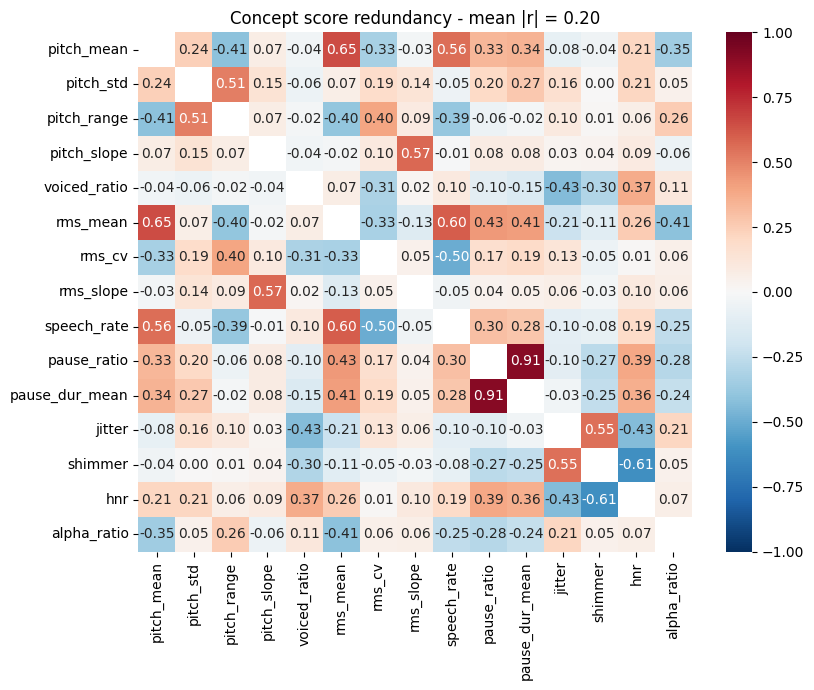

  |r|>0.5: pitch_mean - rms_mean: +0.651
  |r|>0.5: pitch_mean - speech_rate: +0.558
  |r|>0.5: pitch_std - pitch_range: +0.510
  |r|>0.5: pitch_slope - rms_slope: +0.572
  |r|>0.5: rms_mean - speech_rate: +0.602
  |r|>0.5: pause_ratio - pause_dur_mean: +0.912
  |r|>0.5: jitter - shimmer: +0.550
  |r|>0.5: shimmer - hnr: -0.613


In [17]:
corr_matrix = np.corrcoef(C_te.T)
red_mean = float(np.abs(corr_matrix[np.triu_indices(K, 1)]).mean())
fig, ax = plt.subplots(figsize=(8.5, 7))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', ax=ax, cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, mask=np.eye(K, dtype=bool),
            xticklabels=EVAL_CONCEPTS, yticklabels=EVAL_CONCEPTS)
ax.set_title(f'Concept score redundancy - mean |r| = {red_mean:.2f}')
plt.tight_layout(); plt.savefig(RESULTS_DIR / 'concept_redundancy.png', dpi=150); plt.show()
for i in range(K):
    for j in range(i + 1, K):
        if abs(corr_matrix[i, j]) > 0.5:
            print(f'  |r|>0.5: {EVAL_CONCEPTS[i]} - {EVAL_CONCEPTS[j]}: {corr_matrix[i, j]:+.3f}')

## 7 · Controllability - intervention curves

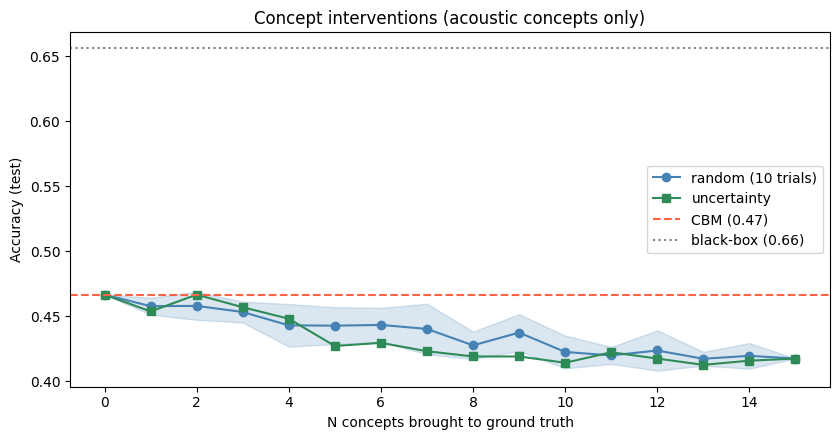

Random: 0.467 -> 0.417   Uncertainty: 0.467 -> 0.417


In [18]:
def apply_intervention(C_pred, C_gt, order_idx, n_int):
    C_int = C_pred.copy()
    if n_int > 0:
        rows = np.arange(len(C_pred))[:, None]
        cols = order_idx[:, :n_int]
        C_int[rows, cols] = C_gt[rows, cols]
    return C_int

N_TRIALS = 10
rng_i = np.random.default_rng(xc.SEED)
rand_mean, rand_std = [], []
for n_int in range(K + 1):
    accs = []
    for _ in range(N_TRIALS):
        order = np.tile(rng_i.permutation(K), (len(C_te), 1))
        accs.append(float((cbm.predict(apply_intervention(C_te, C_gt_te, order, n_int)) == y_te).mean()))
    rand_mean.append(np.mean(accs)); rand_std.append(np.std(accs))
rand_mean, rand_std = np.array(rand_mean), np.array(rand_std)

unc_order = np.argsort(np.abs(C_te - 0.5), axis=1)
unc_curve = np.array([float((cbm.predict(apply_intervention(C_te, C_gt_te, unc_order, n)) == y_te).mean())
                      for n in range(K + 1)])

fig, ax = plt.subplots(figsize=(8.5, 4.5))
ax.plot(range(K + 1), rand_mean, marker='o', color='steelblue', label='random (10 trials)')
ax.fill_between(range(K + 1), rand_mean - rand_std, rand_mean + rand_std, alpha=0.2, color='steelblue')
ax.plot(range(K + 1), unc_curve, marker='s', color='seagreen', label='uncertainty')
ax.axhline(cbm_m['accuracy'], color='tomato', linestyle='--', label=f"CBM ({cbm_m['accuracy']:.2f})")
ax.axhline(mlp_m['accuracy'], color='gray', linestyle=':', label=f"black-box ({mlp_m['accuracy']:.2f})")
ax.set_xlabel('N concepts brought to ground truth'); ax.set_ylabel('Accuracy (test)')
ax.set_title('Concept interventions (acoustic concepts only)')
ax.legend(); plt.tight_layout(); plt.savefig(RESULTS_DIR / 'intervention_curve.png', dpi=150); plt.show()
print(f'Random: {rand_mean[0]:.3f} -> {rand_mean[-1]:.3f}   Uncertainty: {unc_curve[0]:.3f} -> {unc_curve[-1]:.3f}')

## 7bis · CEM evaluation

The CEM is evaluated separately from the linear CBM because concept importance
is not given by a logistic-regression coefficient. We therefore use concept
accuracy, ground-truth interventions (random / uncertainty / targeted),
per-concept ablations and paired significance tests. Note: the targeted policy
uses oracle knowledge of which concepts are wrongly predicted, so it is a
diagnostic upper bound, not a realistic annotator-free workflow.


In [19]:
# Rebuild the CEM exactly as trained in NB2 (same class, in_dim and K) and
# load the saved weights: no retraining, no NB2 in-memory dependencies.
cem = xc.ConceptEmbeddingModel(in_dim=X_emb_tr_sc.shape[1], n_concepts=K).to(DEVICE)
cem.load_state_dict(torch.load(MODEL_DIR / 'cem.pt', map_location=DEVICE))
cem.eval()

X_te_t = torch.tensor(X_emb_te_sc, dtype=torch.float32).to(DEVICE)
C_gt_t = torch.tensor(C_gt_te, dtype=torch.float32).to(DEVICE)

with torch.no_grad():
    cem_logits, cem_p, _ = cem(X_te_t)

y_pred_cem = cem_logits.cpu().argmax(1).numpy()
cem_prob = torch.softmax(cem_logits, dim=1).cpu().numpy()
p_cem = cem_p.cpu().numpy()
cem_m = xc.metrics_report(y_te, y_pred_cem)
print('CEM:', cem_m)

# NB2 <-> NB3 consistency: must reproduce the CEM metrics saved in summary.json
ref_cem = json.load(open(RESULTS_DIR / 'summary.json'))['cem']['accuracy']
assert abs(cem_m['accuracy'] - ref_cem) < 0.01, (
    f'CEM acc {cem_m["accuracy"]:.3f} != NB2 {ref_cem:.3f}: reconstruction mismatch')
print(f'[OK] NB2<->NB3 CEM consistency verified ({cem_m["accuracy"]:.3f} == {ref_cem:.3f})')

# concept accuracy against ground-truth binarized acoustic concepts
cem_concept_acc = {c: float(((p_cem[:, k] >= 0.5) == C_gt_te[:, k]).mean())
                   for k, c in enumerate(EVAL_CONCEPTS)}
cem_concept_acc_mean = float(np.mean(list(cem_concept_acc.values())))
print(f'CEM concept accuracy mean: {cem_concept_acc_mean:.3f}')
for c, a in cem_concept_acc.items():
    print(f'  {c:16s} {a:.3f}')


CEM: {'accuracy': 0.668, 'ua': 0.6764, 'macro_f1': 0.669}
[OK] NB2<->NB3 CEM consistency verified (0.668 == 0.668)
CEM concept accuracy mean: 0.757
  pitch_mean       0.829
  pitch_std        0.734
  pitch_range      0.732
  pitch_slope      0.626
  voiced_ratio     0.687
  rms_mean         0.811
  rms_cv           0.846
  rms_slope        0.734
  speech_rate      0.748
  pause_ratio      0.790
  pause_dur_mean   0.840
  jitter           0.711
  shimmer          0.702
  hnr              0.819
  alpha_ratio      0.741


Targeted subgroup: {'n_samples': 1219, 'err_mean': 3.716, 'acc_before': 0.6669, 'acc_after': 0.662}


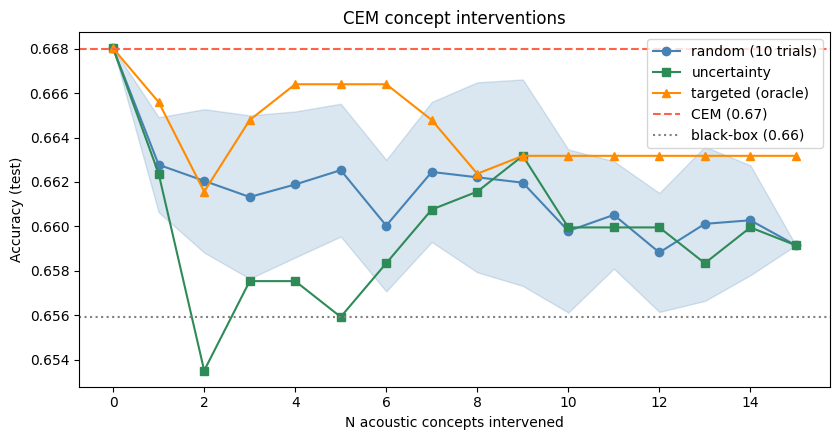

Random: 0.668 -> 0.659   Uncertainty: 0.668 -> 0.659   Targeted: 0.668 -> 0.663


In [20]:
# Interventions on the CEM: p_k := ground truth for the selected concepts.
# Same protocol as the CBM curves (10 trials, per-sample orders).
def cem_intervention_accuracy(order_idx, n_int):
    mask_np = np.zeros((len(C_gt_te), K), dtype=np.float32)
    if n_int > 0:
        rows = np.arange(len(C_gt_te))[:, None]
        cols = order_idx[:, :n_int]
        mask_np[rows, cols] = 1.0
    mask_t = torch.tensor(mask_np, dtype=torch.float32).to(DEVICE)
    with torch.no_grad():
        logits_i, _, _ = cem(X_te_t, c_int=C_gt_t, int_mask=mask_t)
    return float((logits_i.cpu().argmax(1).numpy() == y_te).mean())

N_TRIALS_CEM = 10
rng_cem = np.random.default_rng(xc.SEED)
cem_rand_mean, cem_rand_std = [], []
for n_int in range(K + 1):
    accs = []
    for _ in range(N_TRIALS_CEM):
        order = np.tile(rng_cem.permutation(K), (len(C_gt_te), 1))
        accs.append(cem_intervention_accuracy(order, n_int))
    cem_rand_mean.append(float(np.mean(accs)))
    cem_rand_std.append(float(np.std(accs)))

# uncertainty policy: intervene first on the least confident concepts
cem_unc_order = np.argsort(np.abs(p_cem - 0.5), axis=1)
cem_unc_curve = [cem_intervention_accuracy(cem_unc_order, n) for n in range(K + 1)]

# targeted (oracle) policy: fix only the wrongly predicted concepts
cem_concept_wrong = ((p_cem >= 0.5).astype(np.float32) != C_gt_te)
cem_targ_order = np.argsort(~cem_concept_wrong, axis=1, kind='stable')

def cem_targeted_accuracy(n_int):
    mask_np = np.zeros((len(C_gt_te), K), dtype=np.float32)
    if n_int > 0:
        rows = np.arange(len(C_gt_te))[:, None]
        cols = cem_targ_order[:, :n_int]
        fix = np.take_along_axis(cem_concept_wrong, cols, axis=1)
        mask_np[rows, cols] = fix.astype(np.float32)
    mask_t = torch.tensor(mask_np, dtype=torch.float32).to(DEVICE)
    with torch.no_grad():
        logits_i, _, _ = cem(X_te_t, c_int=C_gt_t, int_mask=mask_t)
    return float((logits_i.cpu().argmax(1).numpy() == y_te).mean())

cem_targ_curve = [cem_targeted_accuracy(n) for n in range(K + 1)]

# subgroup with >= 1 wrong concept: accuracy before/after full targeted fix
cem_n_err = cem_concept_wrong.sum(axis=1).astype(int)
cem_sub = cem_n_err > 0
if cem_sub.any():
    mask_t = torch.tensor(cem_concept_wrong.astype(np.float32)).to(DEVICE)
    with torch.no_grad():
        logits_full, _, _ = cem(X_te_t, c_int=C_gt_t, int_mask=mask_t)
    cem_pred_full = logits_full.cpu().argmax(1).numpy()
    cem_targeted_subgroup = {
        'n_samples': int(cem_sub.sum()),
        'err_mean': round(float(cem_n_err[cem_sub].mean()), 3),
        'acc_before': round(float((y_pred_cem[cem_sub] == y_te[cem_sub]).mean()), 4),
        'acc_after': round(float((cem_pred_full[cem_sub] == y_te[cem_sub]).mean()), 4)}
else:
    cem_targeted_subgroup = {'n_samples': 0, 'err_mean': 0.0,
                             'acc_before': None, 'acc_after': None}
print('Targeted subgroup:', cem_targeted_subgroup)

fig, ax = plt.subplots(figsize=(8.5, 4.5))
ax.plot(range(K + 1), cem_rand_mean, marker='o', color='steelblue',
        label=f'random ({N_TRIALS_CEM} trials)')
ax.fill_between(range(K + 1),
                np.array(cem_rand_mean) - np.array(cem_rand_std),
                np.array(cem_rand_mean) + np.array(cem_rand_std),
                alpha=0.2, color='steelblue')
ax.plot(range(K + 1), cem_unc_curve, marker='s', color='seagreen', label='uncertainty')
ax.plot(range(K + 1), cem_targ_curve, marker='^', color='darkorange', label='targeted (oracle)')
ax.axhline(cem_m['accuracy'], color='tomato', linestyle='--',
           label=f"CEM ({cem_m['accuracy']:.2f})")
ax.axhline(mlp_m['accuracy'], color='gray', linestyle=':',
           label=f"black-box ({mlp_m['accuracy']:.2f})")
ax.set_xlabel('N acoustic concepts intervened'); ax.set_ylabel('Accuracy (test)')
ax.set_title('CEM concept interventions')
ax.legend(); plt.tight_layout()
plt.savefig(RESULTS_DIR / 'cem_intervention_curve.png', dpi=150); plt.show()
print(f'Random: {cem_rand_mean[0]:.3f} -> {cem_rand_mean[-1]:.3f}   '
      f'Uncertainty: {cem_unc_curve[0]:.3f} -> {cem_unc_curve[-1]:.3f}   '
      f'Targeted: {cem_targ_curve[0]:.3f} -> {cem_targ_curve[-1]:.3f}')


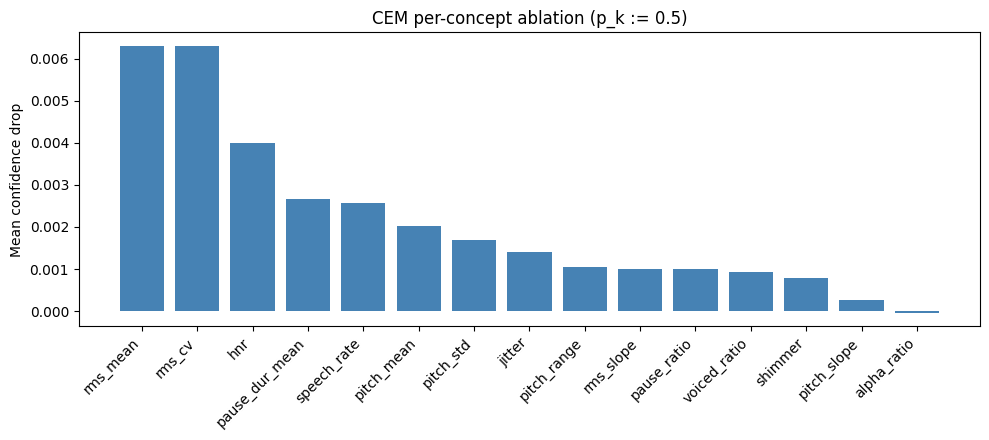

  rms_mean         conf_drop=+0.0063  delta_acc=-0.0064
  rms_cv           conf_drop=+0.0063  delta_acc=+0.0032
  hnr              conf_drop=+0.0040  delta_acc=-0.0008
  pause_dur_mean   conf_drop=+0.0027  delta_acc=-0.0056
  speech_rate      conf_drop=+0.0026  delta_acc=+0.0040


In [21]:
# Per-concept ablation ("interventional importance"):
# force p_k to the neutral value 0.5 and measure the effect on accuracy and on
# the confidence assigned to the original prediction.
cem_base_conf = cem_prob[np.arange(len(y_pred_cem)), y_pred_cem]
cem_acc = float((y_pred_cem == y_te).mean())
cem_ablation = {}
c_neutral = torch.full_like(C_gt_t, 0.5)
for k, c in enumerate(EVAL_CONCEPTS):
    mask_np = np.zeros((len(C_gt_te), K), dtype=np.float32)
    mask_np[:, k] = 1.0
    mask_t = torch.tensor(mask_np, dtype=torch.float32).to(DEVICE)
    with torch.no_grad():
        logits_a, _, _ = cem(X_te_t, c_int=c_neutral, int_mask=mask_t)
        prob_a = torch.softmax(logits_a, dim=1).cpu().numpy()
    pred_a = prob_a.argmax(axis=1)
    conf_a = prob_a[np.arange(len(y_pred_cem)), y_pred_cem]
    cem_ablation[c] = {'acc': float((pred_a == y_te).mean()),
                       'delta_acc': float((pred_a == y_te).mean() - cem_acc),
                       'mean_conf_drop': float((cem_base_conf - conf_a).mean())}

ab_order = sorted(EVAL_CONCEPTS, key=lambda c: cem_ablation[c]['mean_conf_drop'],
                  reverse=True)
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.bar(range(K), [cem_ablation[c]['mean_conf_drop'] for c in ab_order],
       color='steelblue')
ax.set_xticks(range(K)); ax.set_xticklabels(ab_order, rotation=45, ha='right')
ax.set_ylabel('Mean confidence drop')
ax.set_title('CEM per-concept ablation (p_k := 0.5)')
plt.tight_layout(); plt.savefig(RESULTS_DIR / 'cem_ablation.png', dpi=150); plt.show()
for c in ab_order[:5]:
    print(f"  {c:16s} conf_drop={cem_ablation[c]['mean_conf_drop']:+.4f}  "
          f"delta_acc={cem_ablation[c]['delta_acc']:+.4f}")


In [22]:
# Paired significance vs the black-box MLP and the linear CBM
cem_mcnemar_vs_mlp = xc.mcnemar(y_te, y_pred_cem, y_pred_mlp)
cem_mcnemar_vs_cbm = xc.mcnemar(y_te, y_pred_cem, y_pred_cbm)
cem_bootstrap_vs_mlp = xc.bootstrap_diff_ci(y_te, y_pred_cem, y_pred_mlp)
cem_bootstrap_vs_cbm = xc.bootstrap_diff_ci(y_te, y_pred_cem, y_pred_cbm)
print('McNemar CEM vs MLP:', cem_mcnemar_vs_mlp)
print('McNemar CEM vs CBM:', cem_mcnemar_vs_cbm)
print('Bootstrap dACC CEM-MLP:', cem_bootstrap_vs_mlp)
print('Bootstrap dACC CEM-CBM:', cem_bootstrap_vs_cbm)


pred_path = RESULTS_DIR / 'test_predictions.json'
preds = json.load(open(pred_path)) if pred_path.exists() else {'y_true': y_te.tolist()}
preds['cem'] = y_pred_cem.tolist()
xc.atomic_json(pred_path, preds)
print(f"test_predictions.json updated with 'cem' ({len(preds['cem'])} samples)")


McNemar CEM vs MLP: {'n_only_a': 54, 'n_only_b': 39, 'p_value': 0.14617702864715262}
McNemar CEM vs CBM: {'n_only_a': 371, 'n_only_b': 121, 'p_value': 1.5018611209718739e-30}
Bootstrap dACC CEM-MLP: {'diff_mean': 0.012, 'ci95': [-0.0032, 0.0266]}
Bootstrap dACC CEM-CBM: {'diff_mean': 0.2012, 'ci95': [0.166, 0.2337]}
test_predictions.json updated with 'cem' (1241 samples)


## 8 · Coherence / Plausibility - acoustic concepts ONLY
V/A/D are excluded: the fact that "happy has high valence" is the definition
of the annotation, not a discovered alignment. Expectations from SER
psychoacoustics (Scherer 2003): angry = high pitch/energy/rate; sad = low
pitch/energy/rate, more pauses; happy = high pitch/energy.

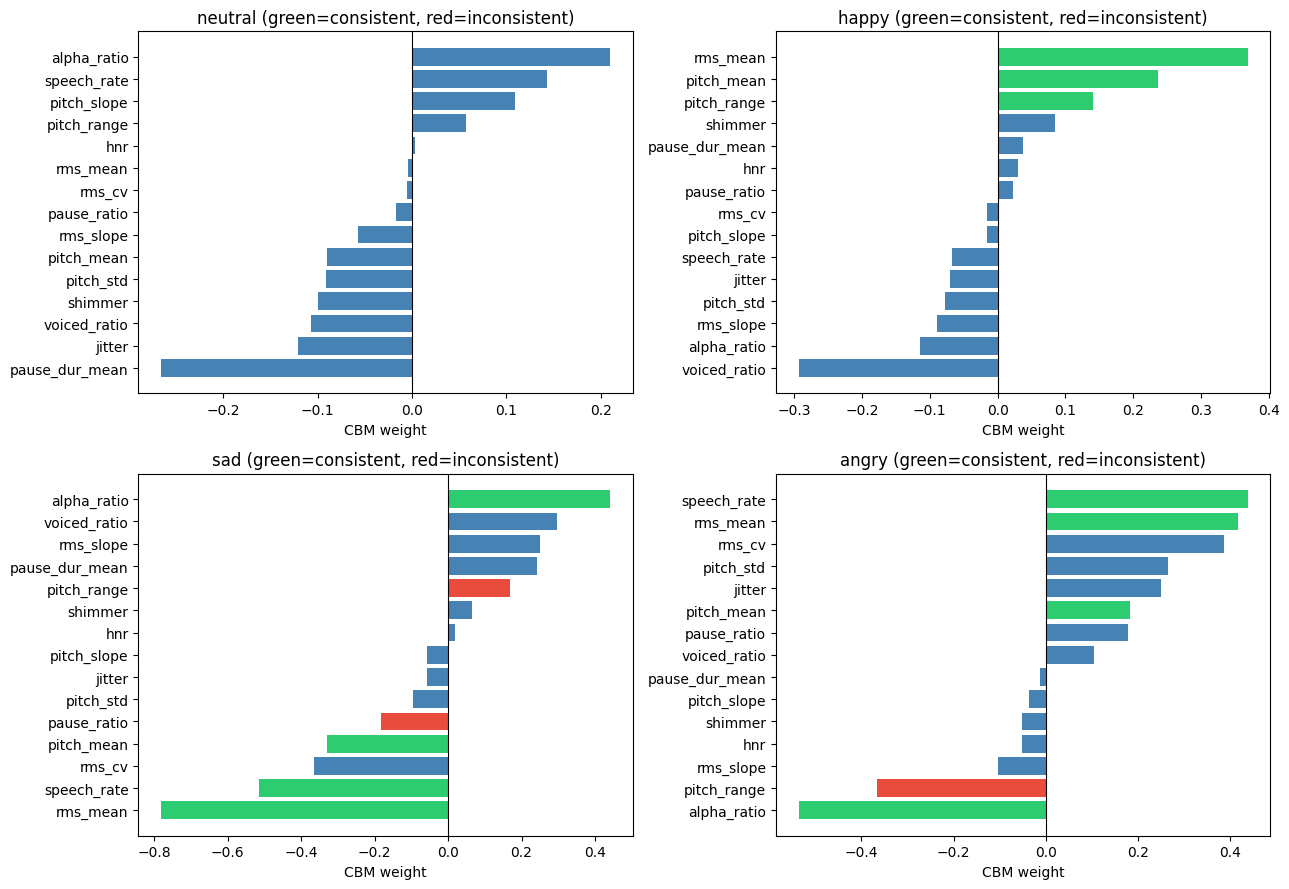

  OK happy    pitch_mean   expected=+ coef=+0.237
  OK happy    rms_mean     expected=+ coef=+0.369
  OK happy    pitch_range  expected=+ coef=+0.140
  OK sad      pitch_mean   expected=- coef=-0.330
  OK sad      rms_mean     expected=- coef=-0.781
  OK sad      speech_rate  expected=- coef=-0.513
  XX sad      pause_ratio  expected=+ coef=-0.183
  XX sad      pitch_range  expected=- coef=+0.169
  OK sad      alpha_ratio  expected=+ coef=+0.441
  OK angry    pitch_mean   expected=+ coef=+0.183
  OK angry    rms_mean     expected=+ coef=+0.417
  OK angry    speech_rate  expected=+ coef=+0.438
  XX angry    pitch_range  expected=+ coef=-0.366
  OK angry    alpha_ratio  expected=- coef=-0.536

Domain alignment (acoustic only): 11/14 (79%)


In [23]:
# Expectations from the literature (Scherer 1986; Banse & Scherer 1996; Juslin &
# Laukka 2003): joy/anger = high and variable F0, high energy; sadness = low
# and stable F0, slow speech rate; anger = more high-frequency energy
# (low alpha_ratio), sadness = darker spectrum (high alpha_ratio).
domain_expectation = {
    'neutral': {},
    'happy':   {'pitch_mean': '+', 'rms_mean': '+', 'pitch_range': '+'},
    'sad':     {'pitch_mean': '-', 'rms_mean': '-', 'speech_rate': '-', 'pause_ratio': '+',
                'pitch_range': '-', 'alpha_ratio': '+'},
    'angry':   {'pitch_mean': '+', 'rms_mean': '+', 'speech_rate': '+',
                'pitch_range': '+', 'alpha_ratio': '-'},
}
coefs = clf_con.coef_
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
total, aligned = 0, 0
for ax, (emo_id, emo_name) in zip(axes.flat, enumerate(xc.LABEL_NAMES)):
    w = coefs[emo_id]; si = np.argsort(w)
    names = [EVAL_CONCEPTS[i] for i in si]; vals = w[si]
    exp = domain_expectation[emo_name]
    cols = []
    for nm, v in zip(names, vals):
        e = exp.get(nm)
        if e is None:
            cols.append('steelblue')
        elif (e == '+' and v > 0) or (e == '-' and v < 0):
            cols.append('#2ecc71')
        else:
            cols.append('#e74c3c')
    ax.barh(names, vals, color=cols); ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f'{emo_name} (green=consistent, red=inconsistent)'); ax.set_xlabel('CBM weight')
plt.tight_layout(); plt.savefig(RESULTS_DIR / 'plausibility.png', dpi=150); plt.show()

for emo_id, emo_name in enumerate(xc.LABEL_NAMES):
    for concept, direction in domain_expectation[emo_name].items():
        w = coefs[emo_id, EVAL_CONCEPTS.index(concept)]
        ok = (direction == '+' and w > 0) or (direction == '-' and w < 0)
        aligned += int(ok); total += 1
        print(f'  {"OK" if ok else "XX"} {emo_name:8s} {concept:12s} expected={direction} coef={w:+.3f}')
print(f'\nDomain alignment (acoustic only): {aligned}/{total} ({100 * aligned / total:.0f}%)')

## 9 · Summary

In [24]:
summary_eval = {
    'metrics': {'cbm': cbm_m, 'baseline_linear': xc.metrics_report(y_te, y_pred_base), 'mlp_blackbox': mlp_m},
    'faithfulness': {
        'AOPC_comprehensiveness': AOPC_comp, 'AOPC_comprehensiveness_random': AOPC_comp_rand,
        'AOPC_sufficiency': AOPC_suff, 'AOPC_sufficiency_random': AOPC_suff_rand,
        'prediction_agreement_vs_mlp': agreement,
        'fidelity_distilled': fidelity,
        'label_rand_acc_mean': float(np.mean(shuf_acc)),
        'label_rand_importance_spearman': float(np.mean(shuf_rho)),
        'label_rand_null_spearman': float(np.mean(null_rho)),
        'param_rand_importance_spearman': float(np.mean(param_rho)),
    },
    'consistency_loso': {'acc_mean': float(np.mean(loso_acc)), 'acc_std': float(np.std(loso_acc)),
                         'ua_mean': float(np.mean(loso_ua)),
                         'rank_corr_mean': float(np.mean(rhos)), 'rank_corr_std': float(np.std(rhos))},
    'contrastivity': {'mean_cosine_offdiag': cos_mean, 'structural_baseline': expected,
                      'shuffled_baseline': float(np.mean(sh_cos))},
    'covariate_complexity': {'mean_abs_corr_offdiag': red_mean},
    'controllability': {'random': [float(m) for m in rand_mean],
                        'uncertainty': [float(u) for u in unc_curve]},
    'plausibility': {'domain_alignment': f'{aligned}/{total}'},
    'cem': {
        'metrics': cem_m,
        'concept_accuracy_mean': round(cem_concept_acc_mean, 4),
        'concept_accuracy': {c: round(float(v), 4) for c, v in cem_concept_acc.items()},
        'intervention_random_mean': [round(float(x), 4) for x in cem_rand_mean],
        'intervention_random_std': [round(float(x), 4) for x in cem_rand_std],
        'intervention_uncertainty': [round(float(x), 4) for x in cem_unc_curve],
        'intervention_targeted': [round(float(x), 4) for x in cem_targ_curve],
        'intervention_targeted_subgroup': cem_targeted_subgroup,
        'ablation': {c: {k2: round(float(v2), 4) for k2, v2 in d.items()}
                     for c, d in cem_ablation.items()},
        'mcnemar_vs_mlp': cem_mcnemar_vs_mlp,
        'mcnemar_vs_cbm': cem_mcnemar_vs_cbm,
        'bootstrap_vs_mlp': cem_bootstrap_vs_mlp,
        'bootstrap_vs_cbm': cem_bootstrap_vs_cbm,
    },
}
xc.atomic_json(RESULTS_DIR / 'evaluation_summary.json', summary_eval)
print(json.dumps(summary_eval, indent=2, default=float))
print(f'\nResults saved in {RESULTS_DIR}')

{
  "metrics": {
    "cbm": {
      "accuracy": 0.4666,
      "ua": 0.5255,
      "macro_f1": 0.4657
    },
    "baseline_linear": {
      "accuracy": 0.6704,
      "ua": 0.6774,
      "macro_f1": 0.6737
    },
    "mlp_blackbox": {
      "accuracy": 0.6559,
      "ua": 0.6638,
      "macro_f1": 0.6558
    }
  },
  "faithfulness": {
    "AOPC_comprehensiveness": 0.22813264313543083,
    "AOPC_comprehensiveness_random": 0.1487577929827255,
    "AOPC_sufficiency": 0.46168813864755537,
    "AOPC_sufficiency_random": 0.3814419525728685,
    "prediction_agreement_vs_mlp": 0.5165189363416599,
    "fidelity_distilled": 0.5874294923448832,
    "label_rand_acc_mean": 0.32082997582594686,
    "label_rand_importance_spearman": 0.046428571428571416,
    "label_rand_null_spearman": 0.1938157894736842,
    "param_rand_importance_spearman": -0.05375
  },
  "consistency_loso": {
    "acc_mean": 0.46218000000000004,
    "acc_std": 0.020224875772177194,
    "ua_mean": 0.5001599999999999,
    "rank_corr_